In [1]:
import pandas as pd

# Load the data
file_path = "input_proteomics.xlsx"
all_data = pd.read_excel(file_path, sheet_name="all", usecols="A:AJ")

# Filter out unassigned genera
filtered_data = all_data[all_data["Genus"] != "unassigned"]

# Group by genus and calculate sums
group_sums1 = filtered_data.groupby("Genus")[["spec_counts_1"]].sum()
group_sums2 = filtered_data.groupby("Genus")[["spec_counts_2"]].sum()

#group_sums1 = filtered_data.groupby("Genus")[["emPAI_1"]].sum()
#group_sums2 = filtered_data.groupby("Genus")[["emPAI_2"]].sum()

# Calculate relative abundances
group_sums1["Relative_Abundance1"] = (group_sums1 / group_sums1.sum()) * 100
group_sums2["Relative_Abundance2"] = (group_sums2 / group_sums2.sum()) * 100

# Combine the dataframes to calculate averages
combined = pd.merge(
    group_sums1[["Relative_Abundance1"]], 
    group_sums2[["Relative_Abundance2"]], 
    left_index=True, 
    right_index=True
)

# Calculate the average of the relative abundances
combined["Average_Relative_Abundance"] = combined.mean(axis=1)

# Sort by the average in descending order
sorted_combined = combined.sort_values(by="Average_Relative_Abundance", ascending=False)

# Export the result to a CSV file
output_path = "taxonomic_groups_abundance.csv"
sorted_combined.to_csv(output_path)

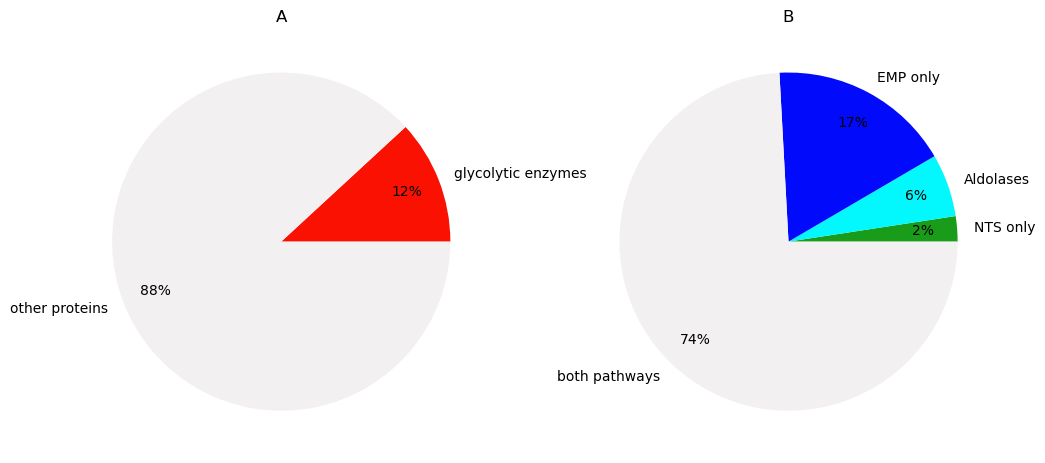

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data from Excel
file_path = "input_proteomics.xlsx"
all_data = pd.read_excel(file_path, sheet_name="all", usecols="A:AJ")
selection_data = pd.read_excel(file_path, sheet_name="selection", usecols="A:B")

# Filter "Candidatus Accumulibacter" data
accumulibacter_data = all_data[all_data["Genus"] == "Candidatus Accumulibacter"].copy()

# Sum abundance for all proteins from Candidatus Accumulibacter
accumulibacter_data["Sum"] = accumulibacter_data[["spec_counts_1", "spec_counts_2"]].sum(axis=1)
total_abundance_accumulibacter = accumulibacter_data["Sum"].sum()

# Identify glycolytic enzymes using "index" in selection_data
glycolytic_data = pd.merge(accumulibacter_data, selection_data, on="index").copy()

# Sum abundance for glycolytic enzymes
glycolytic_data["Sum"] = glycolytic_data[["spec_counts_1", "spec_counts_2"]].sum(axis=1)
total_abundance_glycolytic = glycolytic_data["Sum"].sum()

# Calculate fractions for the first pie chart
glycolytic_fraction = total_abundance_glycolytic / total_abundance_accumulibacter
other_fraction = 1 - glycolytic_fraction

# First Pie Chart: Fraction of Glycolytic Enzymes
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.pie(
    [glycolytic_fraction, other_fraction],
    labels=["glycolytic enzymes", "other proteins"],
    colors=["#fb1102", "#f3f0f2"],
    autopct='%1.0f%%',
    pctdistance=0.8  # Adjust distance of percentages from the center
)
plt.title("A")

# Group glycolytic enzymes based on "rxnID"
enzyme_groups = {
    "NTS only": ["RbuK", "RibE", "RibI", "SBPase", "TKT", "RbuCO"],  # Add enzyme rxnIDs for Group 3
    "Aldolases": ["ALD"],           # Add enzyme rxnIDs for Group 2
    "EMP only": ["GAPDH", "PGK"],  # Add enzyme rxnIDs for Group 1  
}

group_data = []
group_labels = []
group_colors = ['#199c19', '#02f8fc', '#020afc', '#f3f0f2']  # Customize HTML colors

for group_name, rxn_ids in enzyme_groups.items():
    group_sum = glycolytic_data[glycolytic_data["rxnID"].isin(rxn_ids)]["Sum"].sum()
    group_data.append(group_sum)
    group_labels.append(group_name)

# Handle remaining enzymes (Others)
remaining_sum = total_abundance_glycolytic - sum(group_data)
group_data.append(remaining_sum)
group_labels.append("both pathways")

# Second Pie Chart: Relative Abundance of Glycolytic Enzyme Groups
plt.subplot(1, 2, 2)
plt.pie(
    group_data,
    labels=group_labels,
    colors=group_colors,
    autopct='%1.0f%%',
    pctdistance=0.8  # Adjust distance of percentages from the center
)
plt.title("B")

# Save figure as TIFF
plt.savefig("glycolytic_pie_charts.tiff", dpi=150)
plt.show()


In [3]:
import pandas as pd

# Load data from Excel file
file_path = "input_proteomics.xlsx"

# Load the "all" sheet
all_data = pd.read_excel(file_path, sheet_name="all", usecols="A:AJ")
#print("Loaded 'all' data:")
#print(all_data.head())  # Verify the data loaded from 'all'

# Load the "selection" sheet
selection_data = pd.read_excel(file_path, sheet_name="selection", usecols="A:B")
#print("\nLoaded 'selection' data:")
#print(selection_data.head())  # Verify the data loaded from 'selection'

# Step 1: Filter records for Genus "Candidatus Accumulibacter"
candidatus_data = all_data[all_data["Genus"] == "Candidatus Accumulibacter"]
#print("\nFiltered 'Candidatus Accumulibacter' data:")
#print(candidatus_data.head())

# Step 2: Merge candidatus_data with selection_data on the "index" column
merged_data = pd.merge(candidatus_data, selection_data, on="index", how="inner")
#print("\nMerged data (glycolytic proteins in Candidatus Accumulibacter):")
#print(merged_data.head())

# Step 3: Aggregate spec_counts_1 and spec_counts_2 by rxnID
aggregated_data = merged_data.groupby("rxnID")[["spec_counts_1", "spec_counts_2"]].sum().reset_index()
#print("\nAggregated data by rxnID:")
#print(aggregated_data.head())

# Step 4: Calculate ratios
# Calculate the total spec_counts for Candidatus Accumulibacter
total_spec_counts1 = candidatus_data["spec_counts_1"].sum()
total_spec_counts2 = candidatus_data["spec_counts_2"].sum()

# Calculate ratio1 and ratio2
aggregated_data["ratio1"] = aggregated_data["spec_counts_1"] / total_spec_counts1
aggregated_data["ratio2"] = aggregated_data["spec_counts_2"] / total_spec_counts2
#print("\nCalculated ratios for glycolytic proteins:")
#print(aggregated_data[["rxnID", "ratio1", "ratio2"]].head())

# Step 5: Calculate average ratios and convert to Molar
# Define the conversion factor
conversion_factor = (3.5e6 / 1e-15) * (5.5e-3) * 526 * (1 / 6.022e23)

# Calculate average ratio and convert to molar concentration
aggregated_data["average_ratio"] = aggregated_data[["ratio1", "ratio2"]].mean(axis=1)
aggregated_data["Abundance"] = aggregated_data["average_ratio"] * conversion_factor

#print("\nCalculated Abundance (Molar) for glycolytic proteins:")
#print(aggregated_data[["rxnID", "Abundance"]].head())

# Step 6: Save results to CSV
output_data = aggregated_data[["rxnID", "Abundance"]].rename(columns={"rxnID": "Protein"})
output_path = "glycolytic_protein_abundance.csv"
output_data.to_csv(output_path, index=False)

aggregated_data2 = aggregated_data
aggregated_data2["Abundance"] = aggregated_data["Abundance"] * 1e6
#output_data = aggregated_data2[["rxnID", "Abundance"]].rename(columns={"rxnID":"Protein","Abundance": "Cytoplasmic concentration (microM)"})
output_data = aggregated_data2[["rxnID", "Abundance"]].rename(columns={"rxnID": "Protein", "Abundance": "Cytoplasmic concentration (µM)"})

output_path = "glycolytic_protein_micromolar_concentrations.csv"
output_data.to_csv(output_path, index=False)


In [5]:
# Step 7: Normalize individual protein abundances to 100
# Calculate the total abundance of all proteins
total_abundance = aggregated_data["Abundance"].sum()

# Normalize each protein's abundance to a scale of 100
aggregated_data["Normalized Abundance"] = (aggregated_data["Abundance"] / total_abundance) * 100

# Save the normalized abundance values to a new CSV file
output_path = "normalized_protein_abundance_100_scale.csv"
normalized_output = aggregated_data[["rxnID", "Normalized Abundance"]].rename(columns={"rxnID": "Protein"})
normalized_output.to_csv(output_path, index=False)

print(f"CSV file '{output_path}' has been successfully generated!")


CSV file 'normalized_protein_abundance_100_scale.csv' has been successfully generated!
